In [13]:
# !pip install tensorflow
# ============================================================
# AUTOENCODER TRANSFORMER SEQ2SEQ — CÓDIGO CORRIGIDO
# ============================================================

import os
import json
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras import mixed_precision

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

CONFIG = {
    "vocab_size": 72,
    "max_len": 256,
    "embed_dim": 128,
    "ff_dim": 512,
    "num_heads": 8,
    "num_layers": 4,
    "dropout_rate": 0.15,
    "batch_size": 16,
    "learning_rate": 1e-4,
    "epochs": 10,
}

In [14]:
# ============================================================
# 1. CAMADA TRANSFORMERBLOCK REGISTRADA
# ============================================================

@tf.keras.utils.register_keras_serializable(package="MolTransformer")
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, is_decoder=False, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.is_decoder = is_decoder

        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        if self.is_decoder:
            self.cross_att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
            self.layernorm_cross = layers.LayerNormalization(epsilon=1e-6)

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, encoder_output=None, training=False):
        attn_output = self.att(
            query=inputs, value=inputs, key=inputs,
            use_causal_mask=self.is_decoder,
            training=training
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        if self.is_decoder and encoder_output is not None:
            attn_cross = self.cross_att(
                query=out1, value=encoder_output, key=encoder_output,
                training=training
            )
            out1 = self.layernorm_cross(out1 + attn_cross)

        ffn_output = self.ffn(out1, training=training)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
            "is_decoder": self.is_decoder,
        })
        return config



In [3]:
# ============================================================
# 2. CARREGAMENTO DE DADOS E VOCABULÁRIO
# ============================================================

def carregar_vocabulario(path="vocab_oficial.json"):
    if os.path.exists(path):
        with open(path, "r") as f:
            char_to_idx = json.load(f)
        logger.info(f"Vocabulário carregado: {len(char_to_idx)} tokens")
    else:
        raise FileNotFoundError(f"Vocabulário não encontrado em {path}. Rode o pré-processamento primeiro.")

    if '<PAD>' not in char_to_idx:
        char_to_idx['<PAD>'] = 0
    if '<SOS>' not in char_to_idx:
        char_to_idx['<SOS>'] = len(char_to_idx)
    if '<EOS>' not in char_to_idx:
        char_to_idx['<EOS>'] = len(char_to_idx)

    idx_to_char = {v: k for k, v in char_to_idx.items()}
    return char_to_idx, idx_to_char

def carregar_dados(path, n_amostras=50000):
    with open(path, 'r') as f:
        f.readline()
        total_linhas = sum(1 for _ in f)

    p = min(n_amostras / total_linhas, 1.0)
    np.random.seed(42)
    skip_mask = np.random.rand(total_linhas) > p

    def skip_fn(i):
        if i == 0:
            return False
        return skip_mask[i - 1] if (i - 1) < total_linhas else True

    df = pd.read_csv(path, skiprows=lambda i: skip_fn(i))
    all_smiles = df['input_reagentes'].dropna().astype(str).tolist()
    random.shuffle(all_smiles)

    del df
    logger.info(f"Sorteadas {len(all_smiles)} amostras de {total_linhas} linhas totais.")
    return all_smiles

def encode_seq2seq(s_list, char_to_idx, max_len):
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']

    encoder_inputs = []
    decoder_inputs = []
    targets = []

    for s in s_list:
        tokens = [char_to_idx.get(c, 0) for c in s[:max_len - 2]]

        enc = tokens + [0] * (max_len - len(tokens))
        encoder_inputs.append(enc[:max_len])

        dec = [sos] + tokens
        dec = dec + [0] * (max_len - len(dec))
        decoder_inputs.append(dec[:max_len])

        tgt = tokens + [eos]
        tgt = tgt + [0] * (max_len - len(tgt))
        targets.append(tgt[:max_len])

    return (
        np.array(encoder_inputs, dtype=np.int32),
        np.array(decoder_inputs, dtype=np.int32),
        np.array(targets, dtype=np.int32)
    )

In [4]:
# ============================================================
# 3. FUNÇÕES DE LOSS E MÉTRICAS
# ============================================================

def build_loss_weights(vocab_size, char_to_idx):
    weights = np.ones(vocab_size, dtype='float32')
    weights[0] = 0.01  # PAD

    atomos = ['C', 'H', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'l', 'r']
    for ch in atomos:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 20.0

    estruturais = ['[', ']', '=', '>', '.', '+', '-']
    for ch in estruturais:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 15.0

    numeros = ['1','2','3','4','5','6','7','8','9','@','(',')','/','\\']
    for ch in numeros:
        if ch in char_to_idx and char_to_idx[ch] < vocab_size:
            weights[char_to_idx[ch]] = 5.0

    if '<SOS>' in char_to_idx and char_to_idx['<SOS>'] < vocab_size:
        weights[char_to_idx['<SOS>']] = 5.0
    if '<EOS>' in char_to_idx and char_to_idx['<EOS>'] < vocab_size:
        weights[char_to_idx['<EOS>']] = 10.0

    return tf.constant(weights, dtype=tf.float32)

def make_weighted_masked_loss(loss_weights_tensor):
    def weighted_masked_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        loss_fcn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=False, reduction='none'
        )
        loss = loss_fcn(y_true, y_pred)
        batch_weights = tf.gather(loss_weights_tensor, y_true)
        weighted_loss = loss * tf.cast(batch_weights, tf.float32)
        return tf.reduce_mean(weighted_loss)
    return weighted_masked_loss

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    acc = tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)
    mask = tf.cast(mask, tf.float32)
    acc = tf.cast(acc, tf.float32)
    return tf.reduce_sum(acc * mask) / tf.reduce_sum(mask)

In [5]:
# ============================================================
# 4. CONSTRUÇÃO DO MODELO SEQ2SEQ
# ============================================================

def build_seq2seq_model(config, vocab_size):
    max_len = config["max_len"]
    embed_dim = config["embed_dim"]
    ff_dim = config["ff_dim"]
    num_heads = config["num_heads"]
    num_layers = config["num_layers"]
    dropout_rate = config["dropout_rate"]

    # --- ENCODER ---
    enc_inputs = layers.Input(shape=(max_len,), name="encoder_input", dtype='int32')
    x_enc = layers.Embedding(vocab_size, embed_dim, name="encoder_emb")(enc_inputs)
    pos_enc = tf.range(start=0, limit=max_len, delta=1)
    x_enc = x_enc + layers.Embedding(max_len, embed_dim, name="pos_enc")(pos_enc)
    x_enc = layers.Dropout(dropout_rate)(x_enc)

    for i in range(num_layers):
        x_enc = TransformerBlock(
            embed_dim, num_heads, ff_dim, rate=dropout_rate,
            is_decoder=False, name=f"enc_block_{i}"
        )(x_enc)

    encoder_output = x_enc

    # --- DECODER ---
    dec_inputs = layers.Input(shape=(max_len,), name="decoder_input", dtype='int32')
    x_dec = layers.Embedding(vocab_size, embed_dim, name="decoder_emb")(dec_inputs)
    pos_dec = tf.range(start=0, limit=max_len, delta=1)
    x_dec = x_dec + layers.Embedding(max_len, embed_dim, name="pos_dec")(pos_dec)
    x_dec = layers.Dropout(dropout_rate)(x_dec)

    for i in range(num_layers):
        x_dec = TransformerBlock(
            embed_dim, num_heads, ff_dim, rate=dropout_rate,
            is_decoder=True, name=f"dec_block_{i}"
        )(x_dec, encoder_output=encoder_output)

    outputs = layers.Dense(vocab_size, activation="softmax", name="output_dense",
                           dtype='float32')(x_dec)

    model = Model(inputs=[enc_inputs, dec_inputs], outputs=outputs)
    return model


In [6]:
# ============================================================
# 5. TRANSFERÊNCIA DE PESOS DO MODELO ANTIGO
# ============================================================

def transferir_pesos(modelo_antigo, modelo_novo, num_layers):
    modelo_novo.get_layer("encoder_emb").set_weights(
        modelo_antigo.get_layer("emb_old").get_weights()
    )
    modelo_novo.get_layer("decoder_emb").set_weights(
        modelo_antigo.get_layer("emb_old").get_weights()
    )
    logger.info("Embeddings de tokens transferidos.")

    try:
        old_pos = modelo_antigo.get_layer("pos_old").get_weights()
        new_enc_pos = modelo_novo.get_layer("pos_enc").get_weights()
        if old_pos[0].shape == new_enc_pos[0].shape:
            modelo_novo.get_layer("pos_enc").set_weights(old_pos)
            modelo_novo.get_layer("pos_dec").set_weights(old_pos)
            logger.info("Embeddings posicionais transferidos.")
        else:
            logger.warning(f"Shape incompatível pos: {old_pos[0].shape} vs {new_enc_pos[0].shape}. Pulando.")
    except Exception as e:
        logger.warning(f"Embedding posicional não transferido: {e}")

    for i in range(num_layers):
        old_blk = modelo_antigo.get_layer(f"block_old_{i}")
        enc_blk = modelo_novo.get_layer(f"enc_block_{i}")
        dec_blk = modelo_novo.get_layer(f"dec_block_{i}")

        enc_blk.set_weights(old_blk.get_weights())

        dec_blk.att.set_weights(old_blk.att.get_weights())
        dec_blk.ffn.set_weights(old_blk.ffn.get_weights())
        dec_blk.layernorm1.set_weights(old_blk.layernorm1.get_weights())
        dec_blk.layernorm2.set_weights(old_blk.layernorm2.get_weights())

    modelo_novo.get_layer("output_dense").set_weights(
        modelo_antigo.get_layer("dense_old").get_weights()
    )
    logger.info(f"Transferência concluída: {num_layers} blocos processados.")

In [7]:
# ============================================================
# 6. SALVAMENTO E CARREGAMENTO
# ============================================================

def salvar_modelo(model, path="molgpt_autoencoder.keras"):
    model.save(path)
    logger.info(f"Modelo salvo em {path}")

def carregar_modelo(path="molgpt_autoencoder.keras"):
    custom_objects = {
        "TransformerBlock": TransformerBlock,
        "weighted_masked_loss": make_weighted_masked_loss(
            build_loss_weights(CONFIG["vocab_size"], {})
        ),
        "masked_accuracy": masked_accuracy,
    }
    model = tf.keras.models.load_model(path, custom_objects=custom_objects)
    logger.info(f"Modelo carregado de {path}")
    return model

def salvar_vocabulario(char_to_idx, path="molgpt_vocab.json"):
    idx_to_char = {str(v): k for k, v in char_to_idx.items()}
    data = {"char_to_idx": char_to_idx, "idx_to_char": idx_to_char}
    with open(path, "w") as f:
        json.dump(data, f)
    logger.info(f"Vocabulário salvo em {path}")

In [8]:
# ============================================================
# 7. FUNÇÃO DE INFERÊNCIA AUTOREGRESSIVA
# ============================================================

def inferencia_autoregressiva(model, smiles_input, char_to_idx, idx_to_char, max_len=512):
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']

    enc_input = [char_to_idx.get(c, 0) for c in smiles_input[:max_len]]
    enc_input = enc_input + [0] * (max_len - len(enc_input))
    enc_input = np.array([enc_input], dtype=np.int32)

    dec_input = [sos] + [0] * (max_len - 1)
    dec_input = np.array([dec_input], dtype=np.int32)

    resultado = []
    for t in range(max_len - 1):
        preds = model.predict([enc_input, dec_input], verbose=0)
        next_token = np.argmax(preds[0, t])

        if next_token == eos:
            break
        if next_token == 0:
            continue

        resultado.append(idx_to_char.get(next_token, '?'))
        dec_input[0, t + 1] = next_token

    return ''.join(resultado)

def avaliar_reconstrucao(model, smiles_list, char_to_idx, idx_to_char, n_amostras=20):
    sucessos = 0
    for i, smi in enumerate(smiles_list[:n_amostras]):
        recon = inferencia_autoregressiva(model, smi, char_to_idx, idx_to_char)
        match = "OK" if recon == smi else "FAIL"
        if recon == smi:
            sucessos += 1
        if i < 5:
            logger.info(f"  [{match}] Original: {smi[:50]} | Recon: {recon[:50]}")

    taxa = sucessos / n_amostras * 100
    logger.info(f"Taxa de reconstrução exata: {sucessos}/{n_amostras} ({taxa:.1f}%)")
    return taxa


In [9]:
# ============================================================
# 8. PIPELINE DE TREINAMENTO COMPLETO
# ============================================================

def treinar_autoencoder(dataset_path, pesos_antigos_path="molgpt_pesos_finais.weights.h5", n_amostras=50000):
    config = CONFIG.copy()

    # 1. Ativar mixed precision ANTES de tudo
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    logger.info("Mixed precision (float16) ativado.")

    # 2. Carregar vocabulário e dados
    char_to_idx, idx_to_char = carregar_vocabulario("vocab_oficial.json")
    vocab_size = max(len(char_to_idx), config["vocab_size"])
    config["vocab_size"] = vocab_size

    dataset = carregar_dados(dataset_path, n_amostras=150000)
    n_train = int(len(dataset) * 0.9)
    train_smiles = dataset[:n_train]
    val_smiles = dataset[n_train:]

    logger.info(f"Codificando {len(train_smiles)} treino + {len(val_smiles)} val...")
    enc_train, dec_train, tgt_train = encode_seq2seq(train_smiles, char_to_idx, config["max_len"])
    enc_val, dec_val, tgt_val = encode_seq2seq(val_smiles, char_to_idx, config["max_len"])

    # 3. Construir modelo
    model = build_seq2seq_model(config, vocab_size)

    # 4. Construir loss weights e compilar
    loss_weights_tensor = build_loss_weights(vocab_size, char_to_idx)
    loss_fn = make_weighted_masked_loss(loss_weights_tensor)

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=config["learning_rate"], clipnorm=1.0
    )
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=[masked_accuracy])

    # 5. Transferir pesos do modelo antigo (opcional)
    if os.path.exists(pesos_antigos_path):
        logger.info("Transferindo pesos do modelo anterior...")
        seq_len_old = config["max_len"] - 1
        inputs_old = layers.Input(shape=(seq_len_old,))
        x_old = layers.Embedding(vocab_size, config["embed_dim"], name="emb_old")(inputs_old)
        pos_old = tf.range(start=0, limit=seq_len_old, delta=1)
        x_old = x_old + layers.Embedding(seq_len_old, config["embed_dim"], name="pos_old")(pos_old)
        for i in range(config["num_layers"]):
            x_old = TransformerBlock(
                config["embed_dim"], config["num_heads"], config["ff_dim"],
                rate=config["dropout_rate"], is_decoder=False, name=f"block_old_{i}"
            )(x_old)
        outputs_old = layers.Dense(vocab_size, activation="softmax", name="dense_old")(x_old)
        model_old = Model(inputs_old, outputs_old)

        try:
            model_old.load_weights(pesos_antigos_path)
            transferir_pesos(model_old, model, config["num_layers"])
        except Exception as e:
            logger.warning(f"Não foi possível transferir pesos: {e}. Iniciando do zero.")
        del model_old
        K.clear_session()

        # Reconstruir modelo novo (clear_session destrói o grafo)
        model = build_seq2seq_model(config, vocab_size)
        loss_weights_tensor = build_loss_weights(vocab_size, char_to_idx)
        loss_fn = make_weighted_masked_loss(loss_weights_tensor)
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"], clipnorm=1.0
        )
        model.compile(optimizer=optimizer, loss=loss_fn, metrics=[masked_accuracy])
    else:
        logger.info("Pesos antigos não encontrados. Iniciando treino do zero.")

    # 6. Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath="molgpt_autoencoder_best.keras",
            monitor='val_masked_accuracy',
            save_best_only=True, mode='max', verbose=1
        ),
    ]

    # 7. Treinar
    logger.info("Iniciando treinamento...")
    history = model.fit(
        x=[enc_train, dec_train],
        y=tgt_train,
        validation_data=([enc_val, dec_val], tgt_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        callbacks=callbacks,
        verbose=1
    )

    # 8. Salvar modelo final
    salvar_modelo(model, "molgpt_autoencoder_final.keras")
    salvar_vocabulario(char_to_idx)

    # 9. Testar reconstrução
    logger.info("Testando reconstrução...")
    taxa = avaliar_reconstrucao(model, val_smiles[:20], char_to_idx, idx_to_char)

    return model, history, char_to_idx, idx_to_char

def plotar_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['masked_accuracy'], label='Treino', color='blue')
    ax1.plot(history.history['val_masked_accuracy'], label='Validação', color='orange')
    ax1.set_title('Acurácia Mascarada')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Acurácia')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Treino', color='blue')
    ax2.plot(history.history['val_loss'], label='Validação', color='orange')
    ax2.set_title('Loss Ponderada')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
    logger.info("Histórico salvo em training_history.png")

In [10]:
def criar_vocabulario(dataset_path, n_amostras=50000, output_path="vocab_oficial.json"):
    with open(dataset_path, 'r') as f:
        f.readline()
        total_linhas = sum(1 for _ in f)

    p = min(n_amostras / total_linhas, 1.0)
    np.random.seed(42)
    skip_mask = np.random.rand(total_linhas) > p

    def skip_fn(i):
        if i == 0:
            return False
        return skip_mask[i - 1] if (i - 1) < total_linhas else True

    df = pd.read_csv(dataset_path, skiprows=lambda i: skip_fn(i))
    all_smiles = df['input_reagentes'].dropna().astype(str).tolist()
    del df

    vocab = sorted(list(set("".join(all_smiles))))
    char_to_idx = {ch: i + 1 for i, ch in enumerate(vocab)}
    char_to_idx['<PAD>'] = 0
    char_to_idx['<SOS>'] = len(char_to_idx)
    char_to_idx['<EOS>'] = len(char_to_idx)

    with open(output_path, "w") as f:
        json.dump(char_to_idx, f)

    logger.info(f"Vocabulário criado: {len(char_to_idx)} tokens. Salvo em {output_path}")
    return char_to_idx


# RODE ESTA LINHA PRIMEIRO:
criar_vocabulario("dados_reacoes.csv", n_amostras=50000)



{'#': 1,
 '(': 2,
 ')': 3,
 '+': 4,
 '-': 5,
 '.': 6,
 '/': 7,
 '1': 8,
 '2': 9,
 '3': 10,
 '4': 11,
 '5': 12,
 '6': 13,
 '7': 14,
 '9': 15,
 '=': 16,
 '@': 17,
 'A': 18,
 'B': 19,
 'C': 20,
 'E': 21,
 'F': 22,
 'G': 23,
 'H': 24,
 'I': 25,
 'K': 26,
 'L': 27,
 'M': 28,
 'N': 29,
 'O': 30,
 'P': 31,
 'R': 32,
 'S': 33,
 'T': 34,
 'U': 35,
 'V': 36,
 'W': 37,
 'Y': 38,
 'Z': 39,
 '[': 40,
 '\\': 41,
 ']': 42,
 'a': 43,
 'b': 44,
 'c': 45,
 'd': 46,
 'e': 47,
 'f': 48,
 'g': 49,
 'h': 50,
 'i': 51,
 'l': 52,
 'm': 53,
 'n': 54,
 'o': 55,
 'p': 56,
 'r': 57,
 's': 58,
 't': 59,
 'u': 60,
 '<PAD>': 0,
 '<SOS>': 61,
 '<EOS>': 62}

Epoch 1/10
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 4.9037 - masked_accuracy: 0.4111
Epoch 1: saving model to molgpt_ep01.weights.h5

Epoch 1: finished saving model to molgpt_ep01.weights.h5
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 296s 81ms/step - loss: 3.7565 - masked_accuracy: 0.5004 - val_loss: 2.2192 - val_masked_accuracy: 0.6390 - learning_rate: 1.0000e-04
Epoch 2/10
2793/2794 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 2.2185 - masked_accuracy: 0.6551
Epoch 2: saving model to molgpt_ep02.weights.h5

Epoch 2: finished saving model to molgpt_ep02.weights.h5
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 190s 68ms/step - loss: 1.9771 - masked_accuracy: 0.6837 - val_loss: 1.2842 - val_masked_accuracy: 0.7496 - learning_rate: 1.0000e-04
Epoch 3/10
2793/2794 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.4255 - masked_accuracy: 0.7528
Epoch 3: saving model to molgpt_ep03.weights.h5

Epoch 3: finished saving model to molgpt_ep03.weights.h5
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 189s 68ms/step - loss: 1.3071 - mas

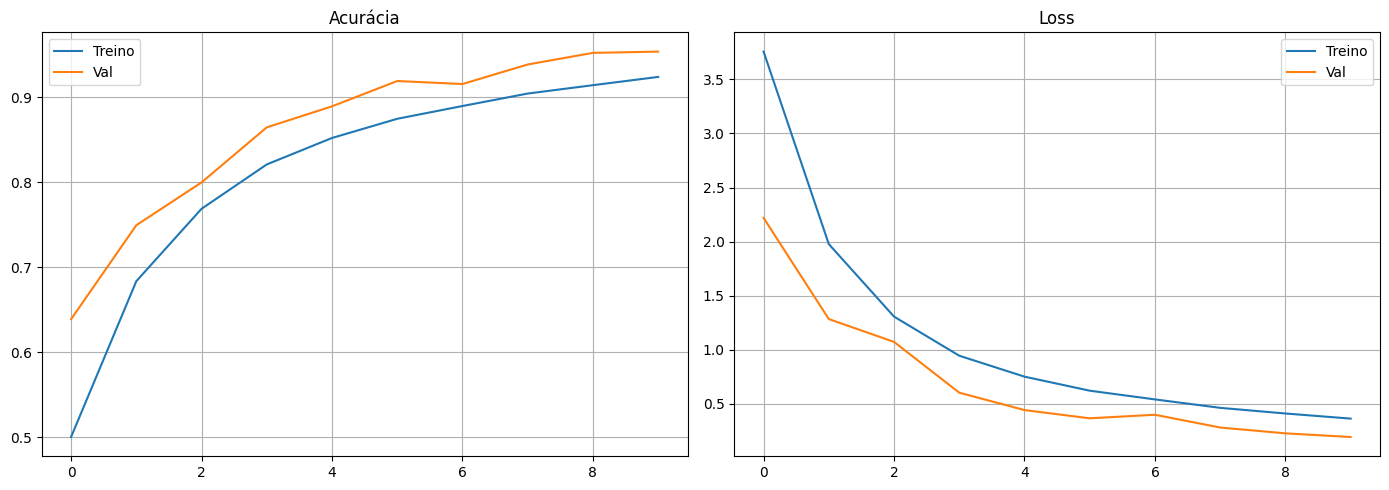

In [15]:
# ============================================================
# CÉLULA ÚNICA — CARREGAR, CODIFICAR, TREINAR E SALVAR
# ============================================================

import os, json, random, logging
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision, backend as K

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Config
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 10
N_AMOSTRAS = 50000

# 1. Ativar mixed precision
mixed_precision.set_global_policy('mixed_float16')
logger.info("Mixed precision ativada.")

# 2. Carregar vocabulário
with open("vocab_oficial.json", "r") as f:
    char_to_idx = json.load(f)
if '<SOS>' not in char_to_idx:
    char_to_idx['<SOS>'] = len(char_to_idx)
if '<EOS>' not in char_to_idx:
    char_to_idx['<EOS>'] = len(char_to_idx)
idx_to_char = {v: k for k, v in char_to_idx.items()}
vocab_size = max(len(char_to_idx), 72)
logger.info(f"Vocabulário: {vocab_size} tokens")

# 3. Sortear 50k reações do CSV sem carregar o arquivo inteiro
dataset_path = "dados_reacoes.csv"
with open(dataset_path, 'r') as f:
    f.readline()
    total_linhas = sum(1 for _ in f)

p = min(N_AMOSTRAS / total_linhas, 1.0)
np.random.seed(42)
skip_mask = np.random.rand(total_linhas) > p

def skip_fn(i):
    if i == 0:
        return False
    return skip_mask[i - 1] if (i - 1) < total_linhas else True

df = pd.read_csv(dataset_path, skiprows=lambda i: skip_fn(i))
all_smiles = df['input_reagentes'].dropna().astype(str).tolist()
random.shuffle(all_smiles)
del df
logger.info(f"Sorteadas {len(all_smiles)} amostras de {total_linhas} linhas")

# 4. Split 90/10
n_train = int(len(all_smiles) * 0.9)
train_smiles = all_smiles[:n_train]
val_smiles = all_smiles[n_train:]

# 5. Codificar Seq2Seq
sos = char_to_idx['<SOS>']
eos = char_to_idx['<EOS>']

def encode_batch(s_list):
    enc, dec, tgt = [], [], []
    for s in s_list:
        tokens = [char_to_idx.get(c, 0) for c in s[:MAX_LEN - 2]]
        enc.append((tokens + [0] * MAX_LEN)[:MAX_LEN])
        dec.append(([sos] + tokens + [0] * MAX_LEN)[:MAX_LEN])
        tgt.append((tokens + [eos] + [0] * MAX_LEN)[:MAX_LEN])
    return (
        np.array(enc, dtype=np.int32),
        np.array(dec, dtype=np.int32),
        np.array(tgt, dtype=np.int32)
    )

logger.info("Codificando dados...")
enc_train, dec_train, tgt_train = encode_batch(train_smiles)
enc_val, dec_val, tgt_val = encode_batch(val_smiles)
logger.info(f"Train: {enc_train.shape}, Val: {enc_val.shape}")

# 6. Criar tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    ((enc_train, dec_train), tgt_train)
).shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    ((enc_val, dec_val), tgt_val)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Libera arrays da RAM
del enc_train, dec_train, tgt_train, enc_val, dec_val, tgt_val

# 7. Construir modelo
model = build_seq2seq_model(CONFIG, vocab_size)

# 8. Loss e otimizador
loss_weights_tensor = build_loss_weights(vocab_size, char_to_idx)
loss_fn = make_weighted_masked_loss(loss_weights_tensor)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=[masked_accuracy])

# 9. Callbacks — checkpoint SÓ DOS PESOS a cada época
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="molgpt_ep{epoch:02d}.weights.h5",
        save_weights_only=True,   # só pesos, leve
        save_best_only=False,     # salva TODAS as épocas
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
]

# 10. Treinar
logger.info("Iniciando treinamento...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# 11. Salvar modelo final completo
model.save("molgpt_autoencoder_final.keras")
logger.info("Modelo final salvo!")

# 12. Plotar
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['masked_accuracy'], label='Treino')
ax1.plot(history.history['val_masked_accuracy'], label='Val')
ax1.set_title('Acurácia'); ax1.legend(); ax1.grid(True)
ax2.plot(history.history['loss'], label='Treino')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

In [ ]:
# Carregar pesos de uma época específica e continuar
model.load_weights("molgpt_ep03.weights.h5")

# Continuar treino da época 4 em diante
history = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=3,  # continua daqui
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

In [21]:
# !pip install rdkit

# ============================================================
# 1. CARREGAR MODELO SALVO
# ============================================================

def carregar_modelo_e_vocab(path_modelo="molgpt_autoencoder_final.keras",
                            path_vocab="vocab_oficial.json"):
    """Carrega modelo + vocabulário prontos para uso."""
    # Vocabulário
    with open(path_vocab, "r") as f:
        char_to_idx = json.load(f)
    if '<SOS>' not in char_to_idx:
        char_to_idx['<SOS>'] = len(char_to_idx)
    if '<EOS>' not in char_to_idx:
        char_to_idx['<EOS>'] = len(char_to_idx)
    idx_to_char = {v: k for k, v in char_to_idx.items()}

    # Modelo
    custom_objects = {
        "TransformerBlock": TransformerBlock,
        "weighted_masked_loss": make_weighted_masked_loss(
            build_loss_weights(len(char_to_idx), char_to_idx)
        ),
        "masked_accuracy": masked_accuracy,
    }
    model = tf.keras.models.load_model(path_modelo, custom_objects=custom_objects)
    logger.info(f"Modelo carregado de {path_modelo}")
    logger.info(f"Vocabulário: {len(char_to_idx)} tokens")

    return model, char_to_idx, idx_to_char

# ============================================================
# 2. INFERÊNCIA AUTOREGRESSIVA (RECONSTRUÇÃO)
# ============================================================

def reconstruir_smiles(model, smiles_input, char_to_idx, idx_to_char, max_len=256):
    sos = char_to_idx['<SOS>']
    eos = char_to_idx['<EOS>']

    enc_input = [char_to_idx.get(c, 0) for c in smiles_input[:max_len]]
    enc_input = enc_input + [0] * (max_len - len(enc_input))
    enc_input = np.array([enc_input], dtype=np.int32)

    dec_input = np.array([[sos] + [0] * (max_len - 1)], dtype=np.int32)

    resultado = []
    for t in range(max_len - 1):
        # Chamada direta em vez de model.predict — 10x mais rápido
        preds = model([enc_input, dec_input], training=False)
        next_token = int(np.argmax(preds[0, t]))

        if next_token == eos:
            break
        if next_token == 0:
            continue

        resultado.append(idx_to_char.get(next_token, '?'))
        dec_input[0, t + 1] = next_token

    return ''.join(resultado)

# ============================================================
# 3. AVALIAÇÃO COMPLETA DO AUTOENCODER
# ============================================================

from rdkit import Chem
from rdkit.Chem import DataStructs, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # silenciar warnings do RDKit

def avaliar_autoencoder(model, smiles_list, char_to_idx, idx_to_char,
                        n_amostras=100, max_len=256):
    """
    Avalia o autoencoder em 4 métricas:
    1. Reconstrução exata (string idêntica)
    2. Validade química da saída (RDKit consegue parsear)
    3. Similaridade de Tanimoto (similaridade molecular real)
    4. Reconstrução canônica (mesma molécula, SMILES diferente mas equivalente)
    """
    exatas = 0
    validas = 0
    canonical_match = 0
    tanimoto_scores = []
    falhas_parse = 0

    for i, smi_original in enumerate(smiles_list[:n_amostras]):
        # Pular SMILES muito longas
        if len(smi_original) > max_len - 2:
            continue

        # Reconstruir
        smi_recon = reconstruir_smiles(model, smi_original, char_to_idx,
                                       idx_to_char, max_len)

        # --- Métrica 1: Reconstrução exata ---
        if smi_recon == smi_original:
            exatas += 1

        # --- Métrica 2: Validade química ---
        mol_recon = Chem.MolFromSmiles(smi_recon)
        if mol_recon is not None:
            validas += 1
        else:
            falhas_parse += 1

        # --- Métrica 3 e 4: Comparação molecular ---
        mol_orig = Chem.MolFromSmiles(smi_original)

        if mol_orig is not None and mol_recon is not None:
            # Canonicalizar ambos
            canon_orig = Chem.MolToSmiles(mol_orig)
            canon_recon = Chem.MolToSmiles(mol_recon)

            # Métrica 4: Match canônico (mesma molécula)
            if canon_orig == canon_recon:
                canonical_match += 1

            # Métrica 3: Similaridade de Tanimoto (fingerprint)
            try:
                fp_orig = AllChem.GetMorganFingerprintAsBitVect(mol_orig, 2, 1024)
                fp_recon = AllChem.GetMorganFingerprintAsBitVect(mol_recon, 2, 1024)
                sim = DataStructs.TanimotoSimilarity(fp_orig, fp_recon)
                tanimoto_scores.append(sim)
            except Exception:
                pass

        # Log dos primeiros 10 exemplos
        if i < 10:
            status = "✓" if smi_recon == smi_original else "✗"
            canon_status = ""
            if mol_recon is not None and mol_orig is not None:
                if Chem.MolToSmiles(mol_orig) == Chem.MolToSmiles(mol_recon):
                    canon_status = " [canônico=✓]"
            logger.info(f"  {status} [{i+1}] Orig: {smi_original[:40]}")
            logger.info(f"       Rec: {smi_recon[:40]}{canon_status}")

    # Calcular estatísticas
    total = min(n_amostras, len(smiles_list))
    taxa_exata = exatas / total * 100
    taxa_valida = validas / total * 100
    taxa_canonical = canonical_match / total * 100
    tanimoto_medio = np.mean(tanimoto_scores) if tanimoto_scores else 0.0
    tanimoto_std = np.std(tanimoto_scores) if tanimoto_scores else 0.0

    # Relatório
    logger.info("=" * 60)
    logger.info("RELATÓRIO DE AVALIAÇÃO DO AUTOENCODER")
    logger.info("=" * 60)
    logger.info(f"Amostras avaliadas:   {total}")
    logger.info(f"Reconstrução exata:   {exatas}/{total} ({taxa_exata:.1f}%)")
    logger.info(f"Match canônico:       {canonical_match}/{total} ({taxa_canonical:.1f}%)")
    logger.info(f"Saída válida (RDKit): {validas}/{total} ({taxa_valida:.1f}%)")
    logger.info(f"Falhas de parse:       {falhas_parse}/{total}")
    logger.info(f"Tanimoto médio:       {tanimoto_medio:.4f} ± {tanimoto_std:.4f}")
    logger.info("=" * 60)

    return {
        "n_amostras": total,
        "reconstrucao_exata": taxa_exata,
        "match_canonico": taxa_canonical,
        "saida_valida": taxa_valida,
        "tanimoto_medio": tanimoto_medio,
        "tanimoto_std": tanimoto_std,
    }

# ============================================================
# 4. TESTE RÁPIDO INTERATIVO
# ============================================================

def teste_rapido(model, char_to_idx, idx_to_char, smiles_list=None):
    """Testa reconstrução em algumas moléculas conhecidas."""
    # Moléculas de teste padrão
    testes_padrao = [
        "CCO",                    # Etanol
        "CC(=O)O",               # Ácido acético
        "c1ccccc1",              # Benzeno
        "CCN(CC)CC",             # Trietilamina
        "OC(=O)C1=CC=CC=C1",     # Ácido benzoico
    ]

    # Se passou lista, pegar 5 amostras aleatórias dela também
    testes = testes_padrao.copy()
    if smiles_list:
        random.shuffle(smiles_list)
        testes.extend(smiles_list[:5])

    logger.info("TESTE DE RECONSTRUÇÃO")
    logger.info("-" * 50)

    for smi in testes:
        recon = reconstruir_smiles(model, smi, char_to_idx, idx_to_char)

        # Validar com RDKit
        mol_in = Chem.MolFromSmiles(smi)
        mol_out = Chem.MolFromSmiles(recon)

        valid_in = "✓" if mol_in else "✗"
        valid_out = "✓" if mol_out else "✗"

        # Comparação canônica
        if mol_in and mol_out:
            canon_match = Chem.MolToSmiles(mol_in) == Chem.MolToSmiles(mol_out)
            canon_str = "mesma molécula" if canon_match else "molécula diferente"
        else:
            canon_str = "N/A"

        exact = "EXATO" if recon == smi else "DIFERENTE"

        logger.info(f"Input:    {smi}")
        logger.info(f"Output:   {recon}")
        logger.info(f"RDKit:    in={valid_in} out={valid_out} | {canon_str} | {exact}")
        logger.info("-" * 30)



In [23]:
# 1. Carregar modelo
model, char_to_idx, idx_to_char = carregar_modelo_e_vocab(
    path_modelo="molgpt_autoencoder_final.keras",
    path_vocab="vocab_oficial.json"
)

# 2. Teste rápido com 5 moléculas conhecidas + print imediato
testes = ["CCO", "CC(=O)O", "c1ccccc1", "CCN(CC)CC", "OC(=O)C1=CC=CC=C1"]

from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print("=" * 60)
print("TESTE DE RECONSTRUÇÃO (5 moléculas)")
print("=" * 60)

for i, smi in enumerate(testes):
    print(f"\n[{i+1}/5] Reconstruindo: {smi}")
    recon = reconstruir_smiles(model, smi, char_to_idx, idx_to_char)

    mol_in = Chem.MolFromSmiles(smi)
    mol_out = Chem.MolFromSmiles(recon)

    canon_match = ""
    if mol_in and mol_out:
        if Chem.MolToSmiles(mol_in) == Chem.MolToSmiles(mol_out):
            canon_match = " | MESMA molécula"
        else:
            canon_match = " | molécula diferente"

    exact = "EXATO" if recon == smi else "DIFERENTE"
    valid = "válida" if mol_out else "INVÁLIDA"

    print(f"  Output: {recon}")
    print(f"  Status: {exact} | {valid}{canon_match}")

print("\n" + "=" * 60)
print("Se os resultados fazem sentido, rode a avaliação completa:")
print("avaliar_autoencoder(model, smiles_list, char_to_idx, idx_to_char, n_amostras=50)")
print("=" * 60)

TESTE DE RECONSTRUÇÃO (5 moléculas)

[1/5] Reconstruindo: CCO
  Output: CO
  Status: DIFERENTE | válida | molécula diferente

[2/5] Reconstruindo: CC(=O)O
  Output: CCO
  Status: DIFERENTE | válida | molécula diferente

[3/5] Reconstruindo: c1ccccc1
  Output: 
  Status: DIFERENTE | válida | molécula diferente

[4/5] Reconstruindo: CCN(CC)CC
  Output: CN(C
  Status: DIFERENTE | INVÁLIDA

[5/5] Reconstruindo: OC(=O)C1=CC=CC=C1
  Output: OC(=O)C1=CC=CC=CC11C11
  Status: DIFERENTE | INVÁLIDA

Se os resultados fazem sentido, rode a avaliação completa:
avaliar_autoencoder(model, smiles_list, char_to_idx, idx_to_char, n_amostras=50)


In [24]:
# Testar com reagentes REAIS do dataset
df = pd.read_csv("dados_reacoes.csv", nrows=50)
reais = df['input_reagentes'].dropna().astype(str).tolist()[:5]

for smi in reais:
    recon = reconstruir_smiles(model, smi, char_to_idx, idx_to_char)
    print(f"Orig:  {smi[:60]}")
    print(f"Rec:   {recon[:60]}")
    print(f"Exact: {recon == smi}")
    print("-" * 40)

Orig:  N#C[S-].[NH4+].II.Cc1c(N)cccc1Cl.O.CO
Rec:   N#C[S-].[NH4+].II.Cc1c(N)ccc1Cl.O.CO
Exact: False
----------------------------------------
Orig:  COc1ccc(CO)cc1Oc1cccc(Cl)c1.c1ccc(P(c2ccccc2)c2ccccc2)cc1.O=
Rec:   COc1ccc(CO)cc1Oc1cccc(Cl)c1.c1ccc(P(c2ccccc2)c2ccccc2)cc1.O=
Exact: False
----------------------------------------
Orig:  O=C(O)OCc1ccccc1.O=C(Cl)C(=O)Cl.ClCCl.CN(C)C=O
Rec:   O=C(O)OCc1ccccc1.O=C(Cl)C(=O)Cl.ClCCl.CN(C)C=O
Exact: True
----------------------------------------
Orig:  COc1nc(S(C)(=O)=O)nc2oc(-c3ccc(C4(NC(=O)OC(C)(C)C)CCC4)cc3)c
Rec:   COc1nc(S(C)(=O)=O)n2nc(-c3cc(-c4CN(C(=O)OC(C)(C)C)CCC4)c3)c(
Exact: False
----------------------------------------
Orig:  CNC(=O)c1cccc(N)c1.O=C(c1cccc2ccccc12)c1c[nH]c2ncnc(Cl)c12
Rec:   CNC(=O)c1cccc(N)c1.O=C(c1ccc2ccccc12)c1[nH][nH]2ccc(Cl)c12
Exact: False
----------------------------------------
